In [1]:
import pandas as pd
import numpy as np
import math

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier


In [2]:
df = pd.read_csv('final_merged_olist_with_geolocation.csv')


In [3]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,seller_city,seller_state,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_lat,customer_lng,seller_lat,seller_lng
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,maua,SP,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,-23.576983,-46.587161,-23.680729,-46.444238
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,maua,SP,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,-23.576983,-46.587161,-23.680729,-46.444238
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,maua,SP,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,-23.576983,-46.587161,-23.680729,-46.444238
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,belo horizonte,SP,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,-12.177924,-44.660711,-19.807681,-43.980427
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,guariba,SP,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,-16.745150,-48.514783,-21.363502,-48.229601


In [4]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value', 'review_id', 'review_score',
       'review_creation_date', 'review_answer_timestamp',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'seller_zip_code_prefix', 'seller_city', 'seller_state',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'customer_lat', 'customer_lng', 'seller_lat',
       'seller_lng'],
      dtype='object')

In [5]:
df1 = df.groupby("order_id").agg({
    "customer_unique_id": "first",
    "order_purchase_timestamp": "first",
    "payment_value": "sum",
    "order_item_id": "count"
})


In [6]:
df1.head()

,customer_unique_id,order_purchase_timestamp,payment_value,order_item_id
order_id,,,,
00010242fe8c5a6d1ba2dd792cb16214,871766c5855e863f6eccc05f988b23cb,2017-09-13 08:59:02,72.19,1
00018f77f2f0320c557190d7a144bdd3,eb28e67c4c0b83846050ddfb8a35d051,2017-04-26 10:53:06,259.83,1
000229ec398224ef6ca0657da4fc703e,3818d81c6709e39d06b2738a8d3a2474,2018-01-14 14:33:31,216.87,1
00024acbcdf0a6daa1e931b038114c75,af861d436cfc08b2c2ddefd0ba074622,2018-08-08 10:00:35,25.78,1
00042b26cf59d7ce69dfabb4e55b4fd9,64b576fb70d441e8f1b2d7d446e483c5,2017-02-04 13:57:51,218.04,1


In [7]:
# Check if there are any duplicate values in the 'customer_unique_id' column
has_duplicates = df1['customer_unique_id'].duplicated().any()

if has_duplicates:
    print("The 'customer_unique_id' column has duplicate values.")
else:
    print("The 'customer_unique_id' column does not have duplicate values.")

# to show if there are any repeat buyers

The 'customer_unique_id' column has duplicate values.


In [8]:
# Label creation: Is customer a repeat buyer?
customer_order_counts = df.groupby("customer_unique_id")["order_id"].nunique()
repeat_buyer_map = (customer_order_counts > 1).astype(int)  # 1 if repeat buyer, else 0

# Add label to the main DataFrame
df["repeat_buyer"] = df["customer_unique_id"].map(repeat_buyer_map)


In [9]:
repeat_buyer_map.value_counts()

,count
order_id,
0,90966
1,2418


In [11]:
# Aggregate useful features
features_df = df.groupby("customer_unique_id").agg({
    "order_id": "nunique",  # number of orders
    "payment_value": "sum",  # total money spent
    "freight_value": "sum",  # total shipping paid
    "review_score": "mean",  # average review score
    "product_category_name": "nunique",  # variety of product categories
    "order_item_id": "count",  # total items bought
    "customer_state": "first",  # customer state (will encode)
    "repeat_buyer": "first",  # label
}).rename(columns={
    "order_id": "num_orders",
    "payment_value": "total_spent",
    "freight_value": "shipping_fee",
    "review_score": "avg_review",
    "product_category_name": "unique_categories",
    "order_item_id": "total_items"
})


In [12]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Encode categorical columns
le = LabelEncoder()
features_df["customer_state"] = le.fit_transform(features_df["customer_state"])

# Features and labels
X = features_df.drop(columns=["repeat_buyer", "num_orders"])
y = features_df["repeat_buyer"]



### random forest ###

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18193
           1       0.97      0.96      0.96       484

    accuracy                           1.00     18677
   macro avg       0.98      0.98      0.98     18677
weighted avg       1.00      1.00      1.00     18677

Accuracy: 0.9980189537934357


In [14]:
def measure_error(y_true, y_pred, label):
    return pd.Series({
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred)
    }, name=label)

# Usage example
error_report = measure_error(y_test, y_pred, 'RandomForest')
print(error_report)


accuracy     0.998019
precision    0.966597
recall       0.956612
f1           0.961578
Name: RandomForest, dtype: float64


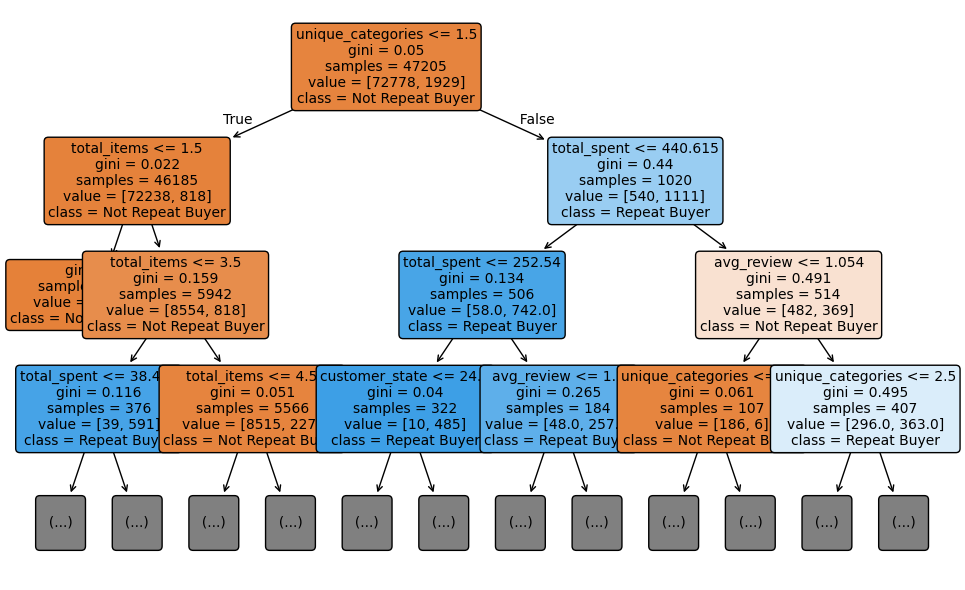

In [15]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Choose one tree from the forest
tree_estimator = rf.estimators_[0]

# Plot a simplified version
plt.figure(figsize=(10, 6))  # adjust as needed
plot_tree(
    tree_estimator,
    max_depth=3,  # LIMIT the depth shown here
    filled=True,
    feature_names=X.columns,
    class_names=["Not Repeat Buyer", "Repeat Buyer"],
    rounded=True,
    fontsize=10
)
plt.tight_layout()
plt.show()


[Text(0, 0.5, 'Relative Importance')]

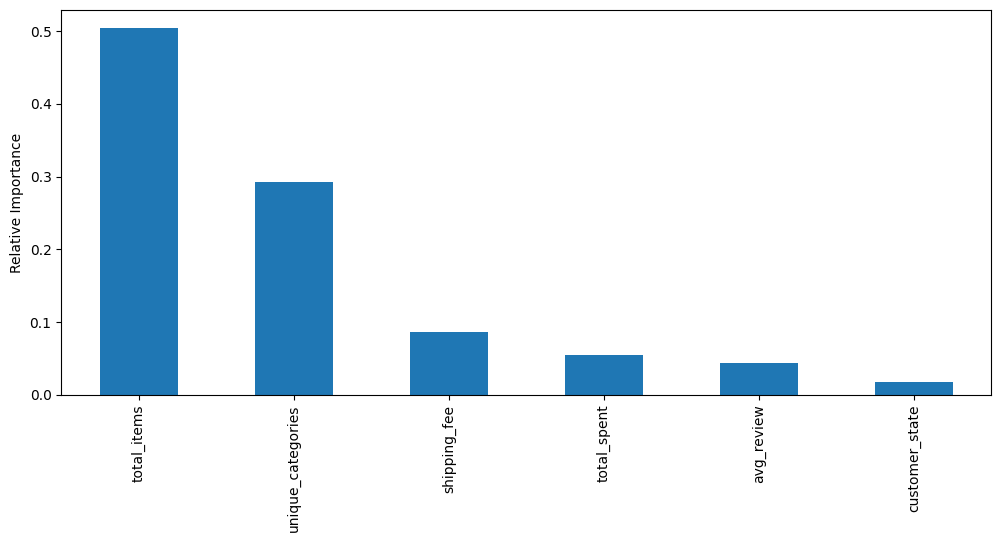

In [16]:
def measure_error(y_true, y_pred, label):
    return pd.Series({'accuracy':accuracy_score(y_true, y_pred),
                      'precision': precision_score(y_true, y_pred),
                      'recall': recall_score(y_true, y_pred),
                      'f1': f1_score(y_true, y_pred)},
                      name=label)
feature_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
fig = plt.figure(figsize=(12,5))
ax = feature_imp.plot(kind='bar')
ax.set(ylabel='Relative Importance')

In [38]:
# Make predictions
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

# Combine error metrics
train_test_full_error = pd.concat([
    measure_error(y_train, y_train_pred, 'train'),
    measure_error(y_test, y_test_pred, 'test')
], axis=1)

# Display results
train_test_full_error


,train,test
accuracy,0.999572,0.999732
precision,0.993824,0.991489
recall,0.989749,0.997859
f1,0.991782,0.994664


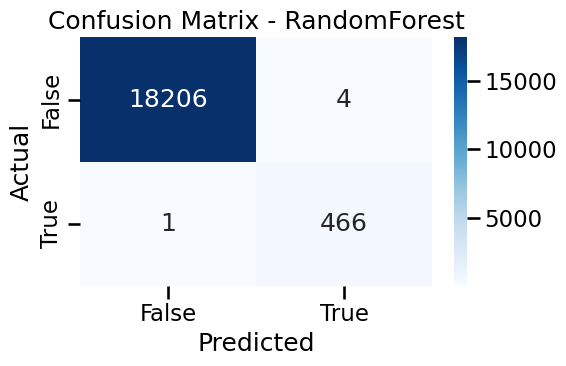

In [39]:


# Confusion matrix for the new model
mat = confusion_matrix(y_test, y_test_pred)

# Plot
sns.set_context('talk')
plt.figure(figsize=(6, 4))  # Optional: adjust figure size
ax = sns.heatmap(mat, annot=True, fmt='d', cmap='Blues')
labels = ['False', 'True']
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.title('Confusion Matrix - RandomForest')
plt.tight_layout()
plt.show()


In [17]:
par_used= rf.get_params()
par_used

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [18]:
# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

# GridSearchCV object
best_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, warm_start=True, n_jobs=-1),
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit the model
best_rf.fit(X_train, y_train)

# Show best parameters
print("Best Parameters:", best_rf.best_params_)
print("Best Accuracy:", best_rf.best_score_)


Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters: {'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Accuracy: 0.998326795788057


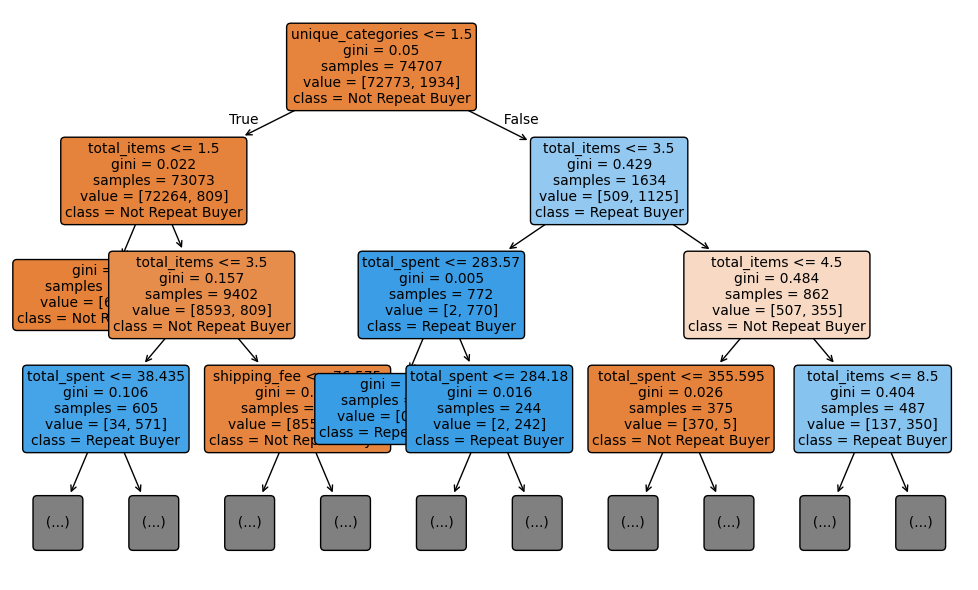

In [19]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
best_model = best_rf.best_estimator_
# Choose one tree from the forest
tree_estimator = best_model.estimators_[0]

# Plot a simplified version
plt.figure(figsize=(10, 6))  # adjust as needed
plot_tree(
    tree_estimator,
    max_depth=3,  # LIMIT the depth shown here
    filled=True,
    feature_names=X.columns,
    class_names=["Not Repeat Buyer", "Repeat Buyer"],
    rounded=True,
    fontsize=10
)
plt.tight_layout()
plt.show()


In [20]:
# Make predictions
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Combine error metrics
train_test_full_error = pd.concat([
    measure_error(y_train, y_train_pred, 'train'),
    measure_error(y_test, y_test_pred, 'test')
], axis=1)

# Display results
train_test_full_error


,train,test
accuracy,1.0,0.998126
precision,1.0,0.972632
recall,1.0,0.954545
f1,1.0,0.963504


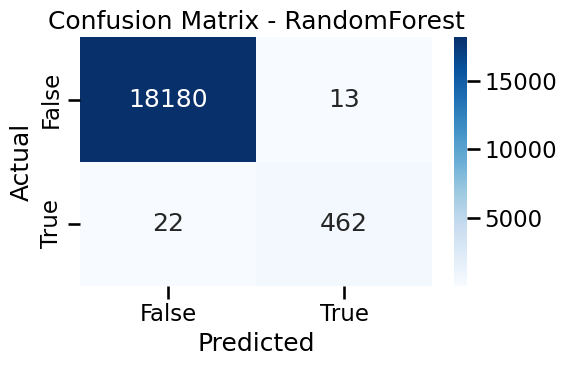

In [21]:


# Confusion matrix for the new model
mat = confusion_matrix(y_test, y_test_pred)

# Plot
sns.set_context('talk')
plt.figure(figsize=(6, 4))  # Optional: adjust figure size
ax = sns.heatmap(mat, annot=True, fmt='d', cmap='Blues')
labels = ['False', 'True']
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.title('Confusion Matrix - RandomForest')
plt.tight_layout()
plt.show()


In [22]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18193
           1       0.97      0.95      0.96       484

    accuracy                           1.00     18677
   macro avg       0.99      0.98      0.98     18677
weighted avg       1.00      1.00      1.00     18677



In [23]:
from sklearn.metrics import precision_recall_curve

# Get predicted probabilities for the positive class (Repeat Buyer = 1)
y_train_pred_prob = best_model.predict_proba(X_train)
y_train_scores = y_train_pred_prob[:, 1]  # Probabilities for class 1

# Compute precision-recall curve
precisions, recalls, thresholds = precision_recall_curve(y_train, y_train_scores)

# Output the arrays (you can also plot them)
precisions, recalls, thresholds


(array([0.0258878, 1.       , 1.       ]),
 array([1., 1., 0.]),
 array([0., 1.]))

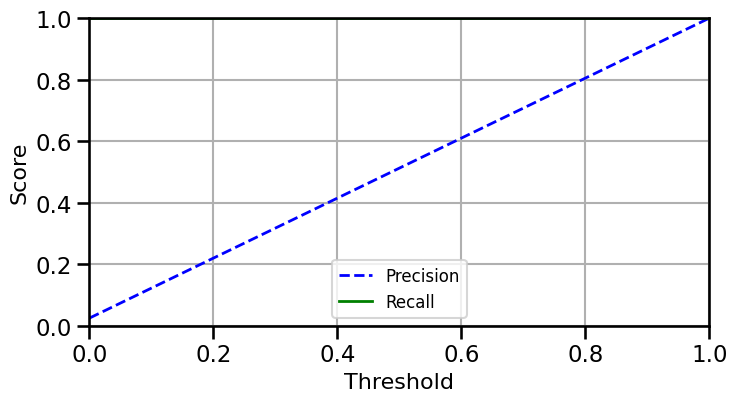

In [24]:
def plot_precision_recall_curve(precisions, recalls, thresholds):
    plt.figure(figsize=(8, 4))  # Make sure this is called before plotting
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
    plt.xlabel("Threshold", fontsize=16)
    plt.ylabel("Score", fontsize=16)
    plt.legend(loc="lower center", fontsize=12)
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.grid(True)
plot_precision_recall_curve(precisions, recalls, thresholds)
plt.show()


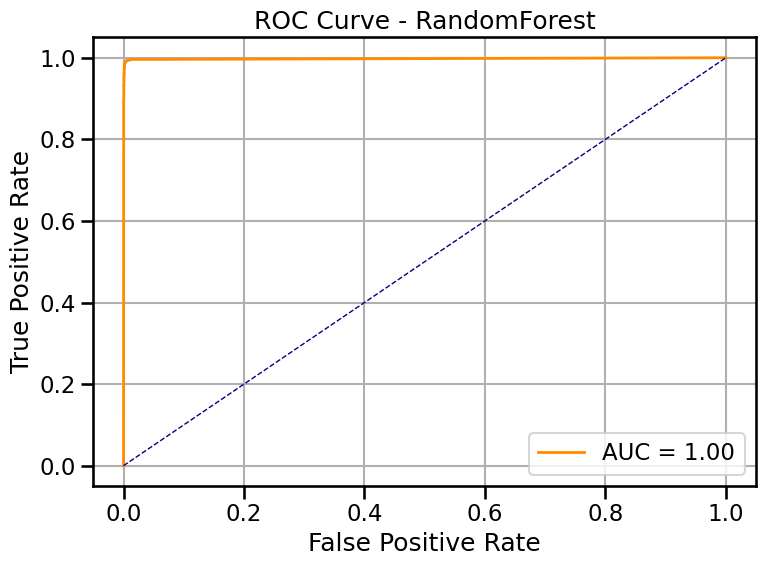

In [25]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for class 1 (positive class)
y_probs = best_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label="AUC = %0.2f" % roc_auc)
plt.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--")  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - RandomForest")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


In [26]:
import joblib
# Assuming your model is named 'rf' or similar
joblib.dump(best_rf, 'saved_model.pkl')

['saved_model.pkl']

In [27]:
joblib.dump(rf, 'saved_model2.pkl')

['saved_model2.pkl']

In [28]:


# # Load the saved GridSearchCV object
# loaded_rf = joblib.load('saved_model.pkl')

# # Use the best estimator (trained RandomForestClassifier)
# best_model_loaded = loaded_rf.best_estimator_

# # Predict or evaluate as usual
# y_pred = best_model_loaded.predict(X_test)


In [29]:
# tree_estimator = best_model_loaded.estimators_[0]

# # Plot a simplified version
# plt.figure(figsize=(10, 6))  # adjust as needed
# plot_tree(
#     tree_estimator,
#     max_depth=3,  # LIMIT the depth shown here
#     filled=True,
#     feature_names=X.columns,
#     class_names=["Not Repeat Buyer", "Repeat Buyer"],
#     rounded=True,
#     fontsize=10
# )
# plt.tight_layout()
# plt.show()